---
# Weight Initialization 
---
In this exercise, you will implement several weight initialization strategies from the lecture.

In [ ]:
%load_ext autoreload
%autoreload 2

import tests
import visual
import weight_init

---
## Theory
---

Each weight initialization strategy defines a distribution from which each weight $W_{ij}$ of a layer is sampled independently, i.e.
$$
W_{ij} \sim \text{some distribution}.
$$
The distribution usually depends on the number of inputs $n_\text{in}$ and the number of outputs $n_\text{out}$ of the layer.  
For example, LeCun initialization samples each weight from a normal distribution with mean $0$ and variance $\frac{1}{n_\text{in}}$:
$$
W_{ij} \sim \mathcal{N}\!\left(0, \frac{1}{n_\text{in}}\right).
$$

For a linear layer, $n_\text{in}$ is the number of columns of the weight matrix $W$, and $n_\text{out}$ is the number of rows of $W$.  
For 2D convolutional layers the "number of inputs" and "number of outputs" are defined differently:
- $n_\text{in} = \text{number of input channels} \times \text{kernel height} \times \text{kernel width}$
- $n_\text{out} = \text{number of output channels} \times \text{kernel height} \times \text{kernel width}$

So we can think of $n_\text{in}$ and $n_\text{out}$ as the "effective input size" and "effective output size" of the layer.

---
## **Task:**

Implement `linear_layer_size` and `conv2d_layer_size` in `weight_init.py`.  

Complete the task by computing $n_\text{in}$ and $n_\text{out}$ given
- the weight matrix of a linear layer,
- the kernel of a 2D convolutional layer.

In [4]:
tests.test_linear_layer_size()

✅ PASS: linear_layer_size is correct.


In [5]:
tests.test_conv2d_layer_size()

✅ PASS: conv2d_layer_size is correct.


---
## Initialization Strategies
---

In the lecture, we have seen several weight initialization strategies, including:
$$\begin{aligned}
\text{LeCun initialization:} \quad &W_{ij} \sim \mathcal{N}\!\left(0, \frac{1}{n_\text{in}}\right) \\[10pt]
\text{Xavier / Glorot initialization:} \quad &W_{ij} \sim \mathcal{N}\!\left(0, \frac{2}{n_\text{in} + n_\text{out}}\right) \\[10pt]
\text{Kaiming He initialization:} \quad &W_{ij} \sim \mathcal{N}\!\left(0, \frac{2}{n_\text{in}}\right)
\end{aligned}$$

## **Task:**

Implement `lecun_init_`, `xavier_init_`, and `kaiming_he_init_` in `weight_init.py`.

Each function:
- Takes a weight tensor and `n_in` and `n_out` as input, so it is **independent of the layer type** (linear or convolutional).
- Initializes the weight tensor **in-place**.
- Should **disable gradient tracking** while initializing the weights.
- Has no return value.

Hints:
- **Important**: PyTorch uses the *standard deviation* $\sigma$ to sample from a normal distribution, so you will need to compute $\sigma$ from the *variance* $\sigma^2$ given in the formulas above.
- Use `torch.no_grad()` to disable gradient tracking.
- PyTorch functions with `_` at the end of their name (e.g. `zero_()`) modify tensors in-place.
- `tensor.zero_()` and `tensor.normal_()` might be helpful.

In [6]:
tests.test_lecun_init()

✅ PASS: lecun_init_ is correct.


In [7]:
tests.test_xavier_init()

✅ PASS: xavier_init_ is correct.


In [8]:
tests.test_kaiming_he_init()

✅ PASS: kaiming_he_init_ is correct.


---
## Visualization
---

Below we visualize the standard deviation of the activations of a 30-layer MLP with 512 neurons per layer, initialized with:
- All weights set to 0.005 (constant)
- LeCun initialization
- Xavier / Glorot initialization
- Kaiming He initialization

We compare MLPs with Sigmoid and ReLU activations.  
If you implemented the initialization strategies correctly, you should see that:
- Constant initialization leads to vanishing activations for Sigmoid and exploding activations for ReLU.
- LeCun and Xavier behave similarly in this case with small but stable activations for Sigmoid, and vanishing activations for ReLU.
- Kaiming He initialization leads to stable activations for ReLU, and small but stable activations for Sigmoid.

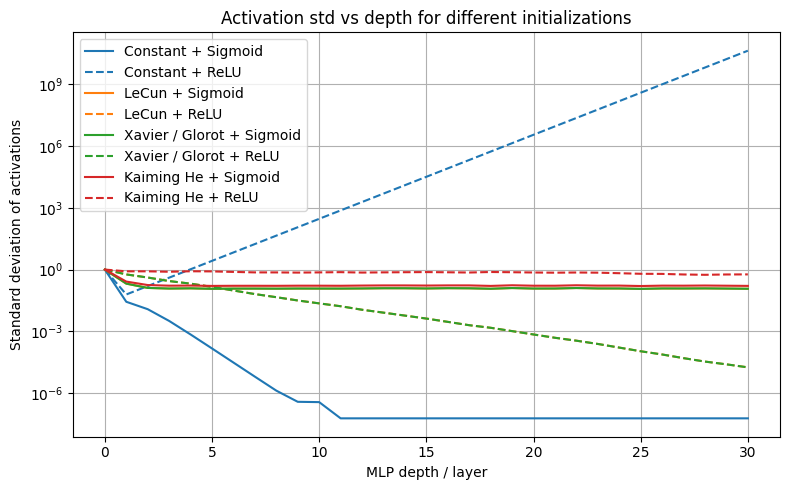

In [9]:
visual.visualize_activation_stds()